# Validity of a diffusive field model for explaining vote behavior over the course of modern french history

In [1], vote statistics are found to be stable over time. Let $\tau = \log(\frac{\pi}{(1-\pi)})$, it is observed than for election between 1990 and 2010:
* The shape of the **centered distrubtion of votes** $\tau-<\tau>$ among different communes is found to be stable (kurtosis, skew, standard deviation).
* The conditional distrubtion of votes controlled by the size of the communes $P(\tau |N)$ is decreasing with $N$ both in mean and in variance.
*  Spatial correlations $C_{\tau}(r)$ show a logarithmic
dependence on r with a cut-off distance L ≈ 300 km.

We aim to test these observed stylized facts over a wider corpus of election data found in [2].

[1] Borghesi, C., & Bouchaud, J. P. (2010). Spatial correlations in vote statistics: a diffusive field model for decision-making. *The European Physical Journal B, 75*(3), 395-404


[2] Julia Cagé et Thomas Piketty (2023) : Une histoire du conflit politique. Élections et inégalités sociales en France, 1789-2022, Paris, Le Seuil.

## 1. Imports and data loading

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from tqdm import tqdm
import matplotlib.cm as cm
from scipy.stats import skew, kurtosis
from matplotlib import pyplot as plt
import re

In [3]:
def load_all_data(directory):
    dfs_by_file = {}
    for dirpath, _, filenames in os.walk(directory):
        for filename in filenames:
            if filename.endswith(".parquet"):
                filepath = os.path.join(dirpath, filename)
                data = pd.read_parquet(filepath)
                relative_path = os.path.relpath(filepath, directory)
                match = re.search(r"(ref\d+|leg\d+|pres\d+)", relative_path)
                id = match.group(1)
                dfs_by_file[id] = data
    print("Data successfully loaded onto the Notebook")
    return dfs_by_file

In [4]:
dfs_by_file = load_all_data("../data/elections/")

Data successfully loaded onto the Notebook


In [5]:
def add_logarithm_turnout_rates(dfs_by_file):
    selected_columns_df = {}
    for key, df in tqdm(dfs_by_file.items(), desc="Processing elections"):
        inscrits = df["inscrits"].astype(float)
        participation = df["ppar"].astype(float)

        # Replace value according to [1]
        participation = np.where(
            participation == 1.0, 1 - 0.5 / inscrits, participation
        )
        participation = np.where(participation == 0.0, 0.5 / inscrits, participation)

        tau = np.log(participation / (1 - participation))
        df["tau"] = tau

        tau_avg = np.nanmean(tau)
        tau_std = np.nanstd(tau)

        # Replace by nan if outside 5 sigma
        df["tau"] = np.where(
            np.abs(df["tau"] - tau_avg) <= 5 * tau_std, df["tau"], np.nan
        )
        df_ = df[df["tau"].notna()].copy()

        df_["tau_c"] = df_["tau"] - tau_avg
        df_["tau_cr"] = df_["tau_c"] / tau_std

        selected_columns_df[key] = df_[
            ["codecommune", "ppar", "tau_c", "tau", "tau_cr", "inscrits", "votants"]
        ]
    return selected_columns_df

In [6]:
selected_columns_df = add_logarithm_turnout_rates(dfs_by_file)

Processing elections: 100%|██████████| 57/57 [00:00<00:00, 58.52it/s]


## 2. Stats

In [7]:
def compute_election_stat(data, metric):
    stats_data = {
        "election": [],
        "year": [],
        "type": [],
        "sd_" + metric: [],
        "skew_" + metric: [],
        "kurtosis_" + metric: [],
        "average_" + metric: [],
    }

    for key, df in data.items():
        if metric in df.columns:
            X = df[metric].astype(float)
            filename = key.split("/")[-1]
            year_match = re.search(r"(\d{4})", filename)
            type_match = re.search(r"^(ref|pres|leg|other)", filename)
            year = year_match.group(1) if year_match else "Unknown"
            election_type = type_match.group(1) if type_match else "Unknown"

            sd_participation = X.std()
            skew_participation = skew(X, nan_policy="omit")
            kurtosis_participation = kurtosis(X, nan_policy="omit")
            average_participation = df["votants"].sum() / df["inscrits"].sum()

            # Store statistics in the dictionary
            stats_data["election"].append(key)
            stats_data["year"].append(year)
            stats_data["type"].append(election_type)
            stats_data["sd_" + metric].append(sd_participation)
            stats_data["skew_" + metric].append(skew_participation)
            stats_data["kurtosis_" + metric].append(kurtosis_participation)
            stats_data["average_" + metric].append(average_participation)

    stats_df = pd.DataFrame(stats_data)

    return stats_df

In [8]:
stats_df = compute_election_stat(selected_columns_df, metric="tau")

In [9]:
stats_df.mean(numeric_only=True)

sd_tau          0.487246
skew_tau        0.325861
kurtosis_tau    1.783706
average_tau     0.736354
dtype: float64

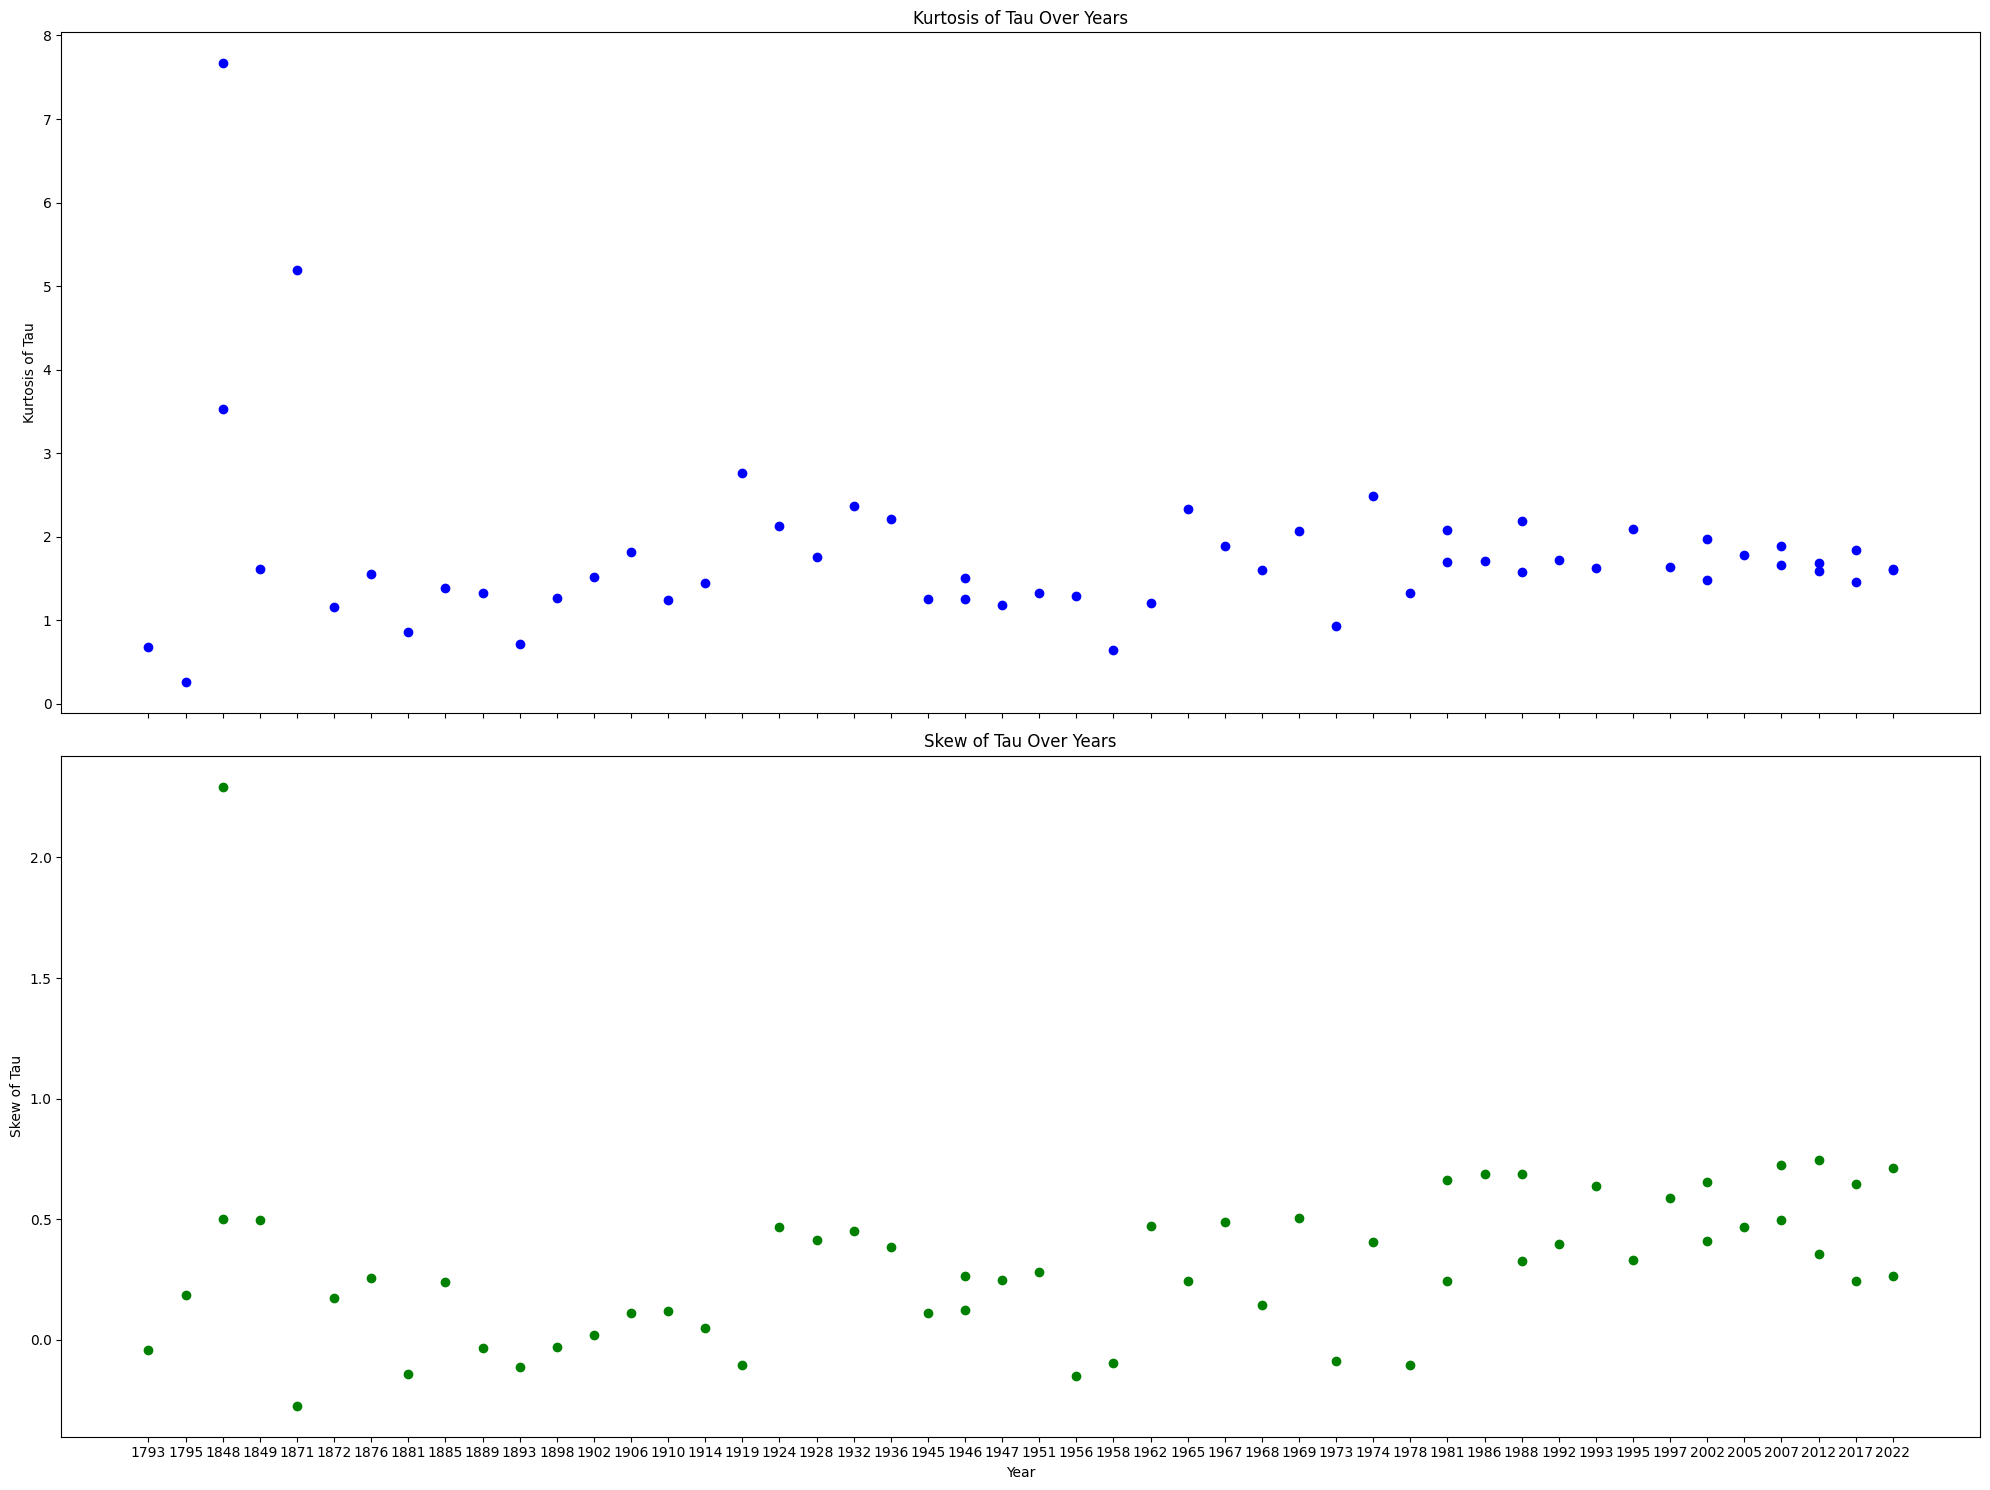

In [10]:
# Sort stats_df by the 'year' column
stats_df_sorted = stats_df.sort_values(by="year")

# Create subplots for kurtosis and skew
fig, axes = plt.subplots(2, 1, figsize=(20, 15), sharex=True)

# Plot kurtosis
axes[0].scatter(stats_df_sorted["year"], stats_df_sorted["kurtosis_tau"], color="blue")
axes[0].set_ylabel("Kurtosis of Tau")
axes[0].set_title("Kurtosis of Tau Over Years")

# Plot skew
axes[1].scatter(stats_df_sorted["year"], stats_df_sorted["skew_tau"], color="green")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Skew of Tau")
axes[1].set_title("Skew of Tau Over Years")

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

We find a smaller skew and a smaller kurtosis that [1], yet we confirm their results for recent election.

## 3. Distribution $\tau - <\tau>$

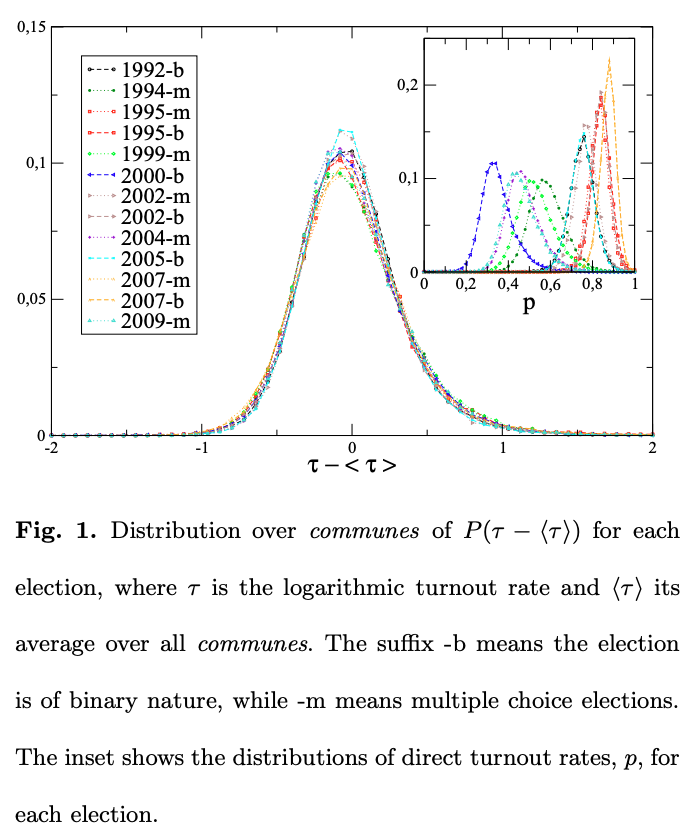

In [11]:
def plot_tau_c_distribution(selected_columns_df):
    """
    Plots the distribution of tau_c for all keys in the given dictionary of DataFrames.

    Parameters:
        selected_columns_df (dict): A dictionary where keys are dataset names and values are DataFrames.
    """
    plt.figure(figsize=(12, 8))

    for key, df in selected_columns_df.items():
        year = re.search(r"\d{4}", key).group(0)
        # if int(year) >=1990 and int(year) <= 2010:
        if "tau_c" in df.columns:
            # Plot the distribution of tau_c using KDE
            sns.kdeplot(df["tau_c"], label=key, fill=False, alpha=0.5)

    # Add labels, legend, and title
    plt.xlabel("tau_c")
    plt.ylabel("Density")
    plt.title("Distribution of tau_c for All Keys")
    plt.legend(loc="upper right", fontsize="small", bbox_to_anchor=(1.2, 1))
    plt.grid(True)

    # Show the plot
    plt.tight_layout()
    plt.show()

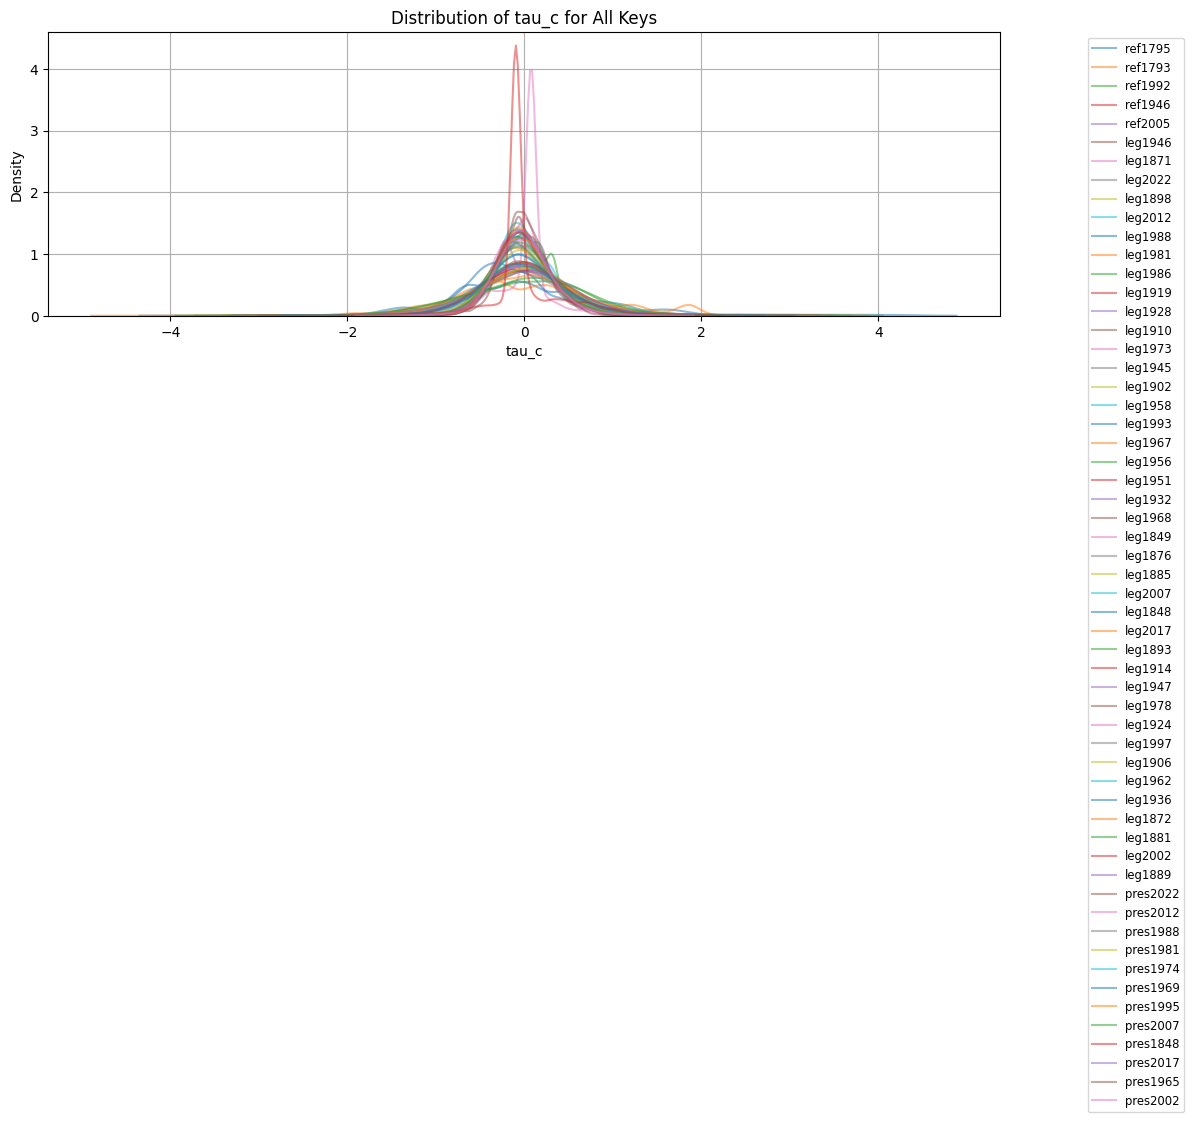

In [12]:
plot_tau_c_distribution(selected_columns_df)

We find similar results.

## 4. Distribution $P(\tau|N)$

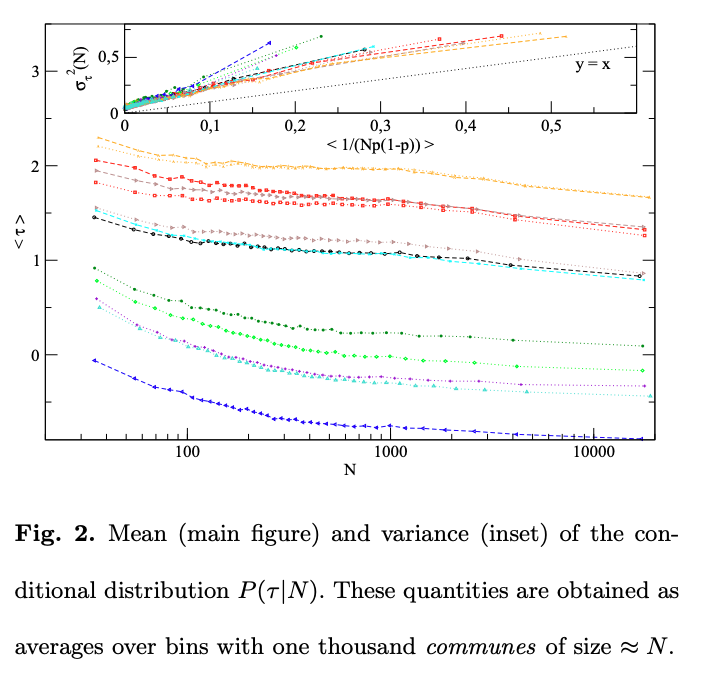

In [13]:
criteria = "inscrits"

In [14]:
def create_size_bins(df, criteria):
    if criteria == "inscrits":
        global_min = 0.0
        global_max = 1.362500e07

    df_sorted = df.sort_values(criteria)
    d = df_sorted[criteria].dropna()

    num_bins = 35  # bin of ~1000 communes

    bin_edges = np.percentile(d, np.linspace(0, 100, num_bins + 1))
    bin_edges = bin_edges[:-1]
    bin_edges = np.concatenate(
        [np.array([global_min]), bin_edges, np.array([global_max])]
    )
    bin_edges = np.sort(bin_edges)

    df = df.copy()
    df.loc[:, "bin"] = np.digitize(df[criteria], bin_edges) - 1

    bin_avg_values = df.groupby("bin")[criteria].mean()

    commune_count = df["bin"].value_counts().sort_index()

    return commune_count, bin_edges, bin_avg_values

In [15]:
def compute_tau_means(data=selected_columns_df, criteria="inscrits", metric="tau"):
    tau_mean_bin = {}
    tau_std_bin = {}
    bin_avg_values_bin = {}

    for key, df in tqdm(data.items(), desc="Processing keys in tau_distributions"):
        df = df.copy()
        df.dropna()

        commune_counts, size_bins, bin_avg_values = create_size_bins(df, criteria)
        bin_indices = np.arange(len(size_bins) - 2)

        if df.empty or criteria not in df.columns or metric not in df.columns:
            tau_mean_bin[key] = pd.Series(0, index=bin_indices, dtype=float)
            continue

        # Assign each 'inscrits' value to a bin using np.digitize
        df.loc[:, "bin"] = np.digitize(df[criteria], size_bins) - 1

        # Compute the mean 'tau' value for each bin
        tau_mean = df.groupby("bin")[metric].mean()
        tau_std = df.groupby("bin")[metric].std()

        # Store the aligned Series in the result dictionary
        tau_mean_bin[key] = tau_mean
        tau_std_bin[key] = tau_std
        bin_avg_values_bin[key] = bin_avg_values

    return tau_mean_bin, tau_std_bin, bin_avg_values_bin

In [16]:
tau_m, tau_s, bin_avg_values_bin = compute_tau_means(
    selected_columns_df, criteria="inscrits", metric="tau"
)

Processing keys in tau_distributions: 100%|██████████| 57/57 [00:00<00:00, 101.79it/s]


In [17]:
def plot_m_N(tau_m, bin_avg_values_bin, election_type="all", years_to_remove=None):
    PHI = {}
    if years_to_remove is None:
        years_to_remove = []  # Initialize as an empty list if not provided

    # Create figure for plotting
    fig, ax = plt.subplots(figsize=(20, 10), dpi=80)

    # Define color map for election years (you can change the colormap)
    colormap = cm.plasma

    # Extract years from keys
    years = []
    for key in tau_m.keys():
        match = re.match(r"(ref|leg|pres)(\d+)", key)
        if match:
            year = match.group(2)
            years.append(int(year))
    normalize = plt.Normalize(
        min(years), max(years)
    )  # Normalize to map years to colors
    colors = {
        year: colormap(normalize(year)) for year in years
    }  # Color map for each year

    for key, df in tau_m.items():
        if election_type != "all" and election_type not in key:
            continue

        match = re.match(r"(ref|leg|pres)(\d+)", key)
        type_ = match.group(1)
        year = match.group(2)

        if year in years_to_remove:
            continue

        color = colors.get(int(year), "black")
        ax.plot(
            bin_avg_values_bin[key],
            df,
            label=f"{type_} {year}",
            linestyle="dashed",
            marker="o",
            linewidth=0.5,
            markersize=2,
            color=color,
        )

    ax.set_xscale("log")

    ax.set_ylabel("Average of tau for the bin of size N")
    ax.set_xlabel("N (nombre d'inscrits)")
    ax.set_title("Average value, $m_N$")
    ax.legend()

    sm = cm.ScalarMappable(cmap=colormap, norm=normalize)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Year")

    # Display the plot
    plt.tight_layout()
    plt.show()

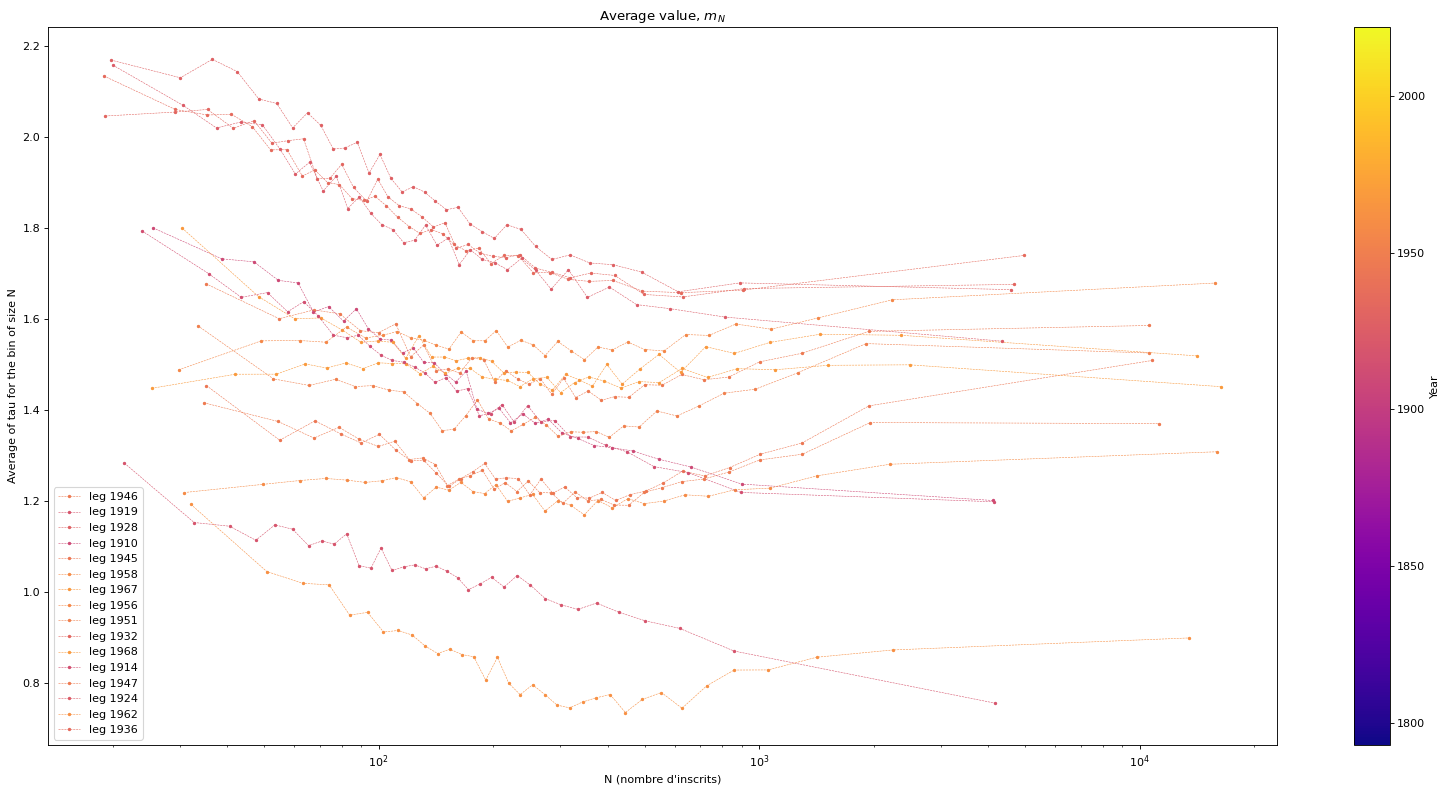

In [27]:
plot_m_N(
    tau_m,
    bin_avg_values_bin,
    election_type="leg",
    years_to_remove=[
        "1871",
        "2017",
        "1898",
        "2012",
        "1988",
        "1981",
        "1986",
        "1973",
        "1902",
        "1993",
        "1849",
        "1876",
        "1885",
        "2007",
        "1848",
        "1893",
        "1978",
        "1997",
        "1906",
        "1872",
        "1881",
        "2002",
        "1889",
        "2022",
    ],
)

In [19]:
def plot_sigma(
    tau_m,
    tau_s,
    bin_avg_values_bin,
    h=1,
    omega=-3 / 4,
    election_type="pres",
    elections_to_remove=None,
    remove_constante_component=True,
    b={},
    remove_component_2=True,
    a={},
):
    if elections_to_remove is None:
        elections_to_remove = []  # Initialize as an empty list if not provided

    # Define line styles and markers for different election types
    line_styles = {"pres": "-", "leg": "--", "ref": "-."}
    marker_styles = {"pres": "o", "leg": "s", "ref": "D"}

    years = sorted(
        set(
            int(re.search(r"(ref|leg|pres)(\d+)", key).group(2))  # Extract year
            for key in tau_s.keys()
            if re.search(r"(ref|leg|pres)(\d+)", key)  # Match pattern
        )
    )

    # Create a colormap based on the years
    colormap = (
        cm.plasma
    )  # Choose the color map (can change to others like 'viridis', 'inferno')
    normalize = plt.Normalize(min(years), max(years))
    colors = {year: colormap(normalize(year)) for year in years}

    # Create the figure (only one plot as specified)
    fig, ax = plt.subplots(figsize=(20, 10), dpi=80)

    # Plot the x = y line
    ax.plot([0, 0.3], [0, 0.3], color="red", linestyle="--", label="x = y")

    # Set the plot title based on the election type
    if election_type == "pres":
        ax.set_title("Presidential Elections")
    elif election_type == "leg":
        ax.set_title("Legislative Elections")
    elif election_type == "ref":
        ax.set_title("Referendum Elections")
    else:
        ax.set_title("All Elections")

    # Set axis labels and grid
    ax.set_ylabel("gamma_n = Sigma_n squared - <h/(Np(1-p))>")
    ax.set_xlabel(f"N ** ({omega}) (nombre d'inscrits)")
    ax.grid(True)

    for key, df in tau_s.items():
        # If the user specified an election type, only plot that type
        if election_type != "all" and election_type not in key:
            continue  # Skip non-matching election types

        # If the election is in the removal list, skip it
        if any(election in key for election in elections_to_remove):
            continue  # Skip this key if it's in the exclusion list

        # Extract the year correctly (handle cases like '1871juil')
        year = re.search(r"(ref|leg|pres)(\d+)", key).group(2)
        election_type_ = re.search(r"(ref|leg|pres)(\d+)", key).group(1)

        # Get the color for the year
        color = colors.get(int(year), "black")  # Default to black if year not in map

        # Get line style and marker based on election type
        line_style = line_styles.get(election_type_, "-")
        marker_style = marker_styles.get(election_type_, "x")

        # Calculate the values
        p = np.exp(tau_m[key].mean()) / (1 + np.exp(tau_m[key].mean()))
        if remove_constante_component:
            x = df**2 - h / (bin_avg_values_bin[key] * p * (1 - p)) - b[key]
            if remove_component_2:
                x = x / a[key]
                ax.plot(np.linspace(0, 0.1, 100), np.linspace(0, 0.1, 100))
        else:
            x = df**2 - h / (bin_avg_values_bin[key] * p * (1 - p))

        y = (p * (1 - p) * bin_avg_values_bin[key]) ** omega
        # y =  bin_avg_values_bin[key]** omega

        # Create label with election type and year
        label = f"{election_type_} {year}"

        # Plot data with dynamic line style, marker, and color
        ax.plot(
            y,
            x,
            label=label,
            color=color,
            linestyle=line_style,
            marker=marker_style,
            linewidth=1.5,
            markersize=6,
        )

    # Show the legend
    ax.legend()

    # Show colorbar to indicate the year
    sm = cm.ScalarMappable(cmap=colormap, norm=normalize)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)  # Explicitly link the colorbar to the axes
    cbar.set_label("Year")

    # Display the plot
    plt.tight_layout()
    plt.show()

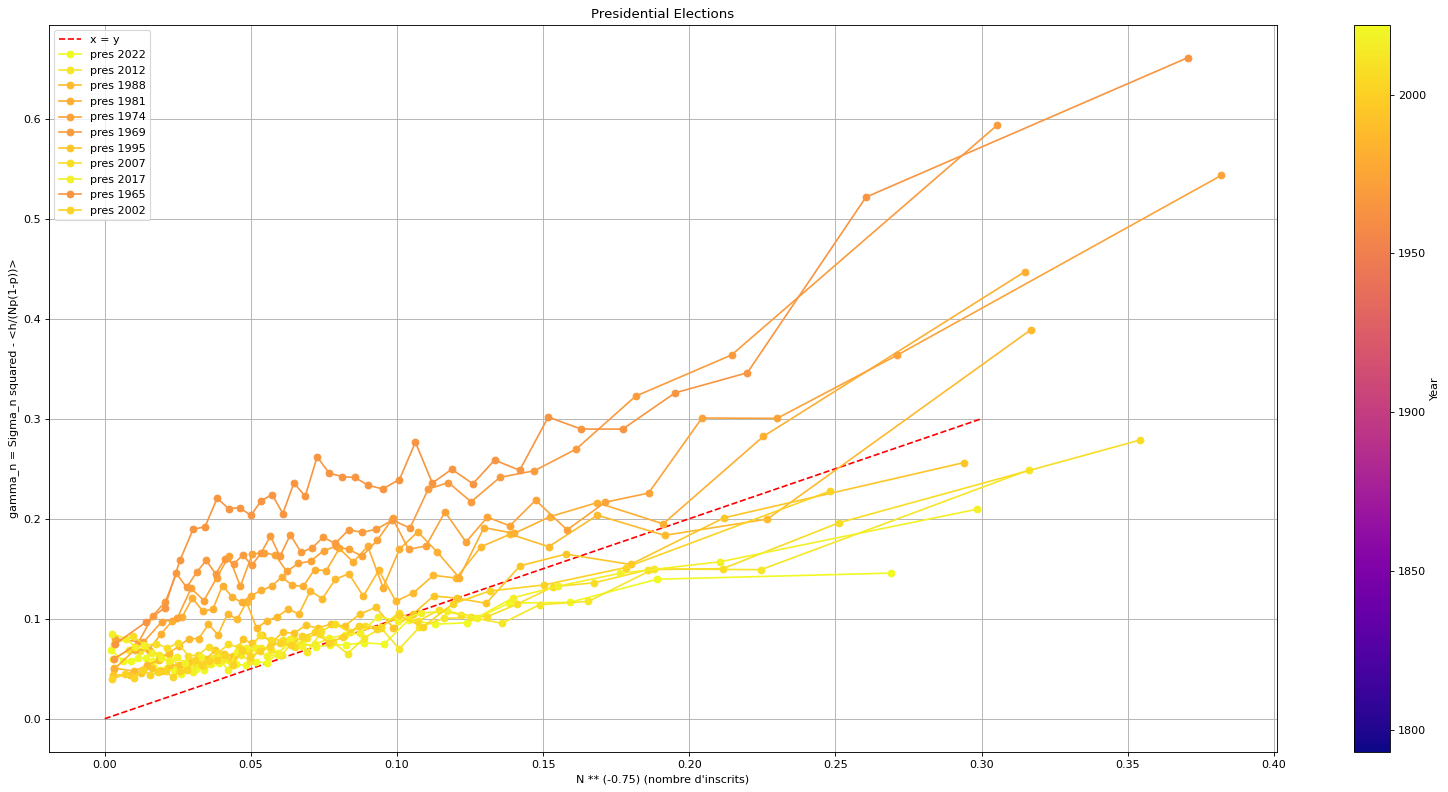

In [20]:
plot_sigma(
    tau_m,
    tau_s,
    bin_avg_values_bin,
    election_type="pres",
    elections_to_remove=["1848"],
    remove_constante_component=False,
    b={},
    remove_component_2=False,
    a={},
)

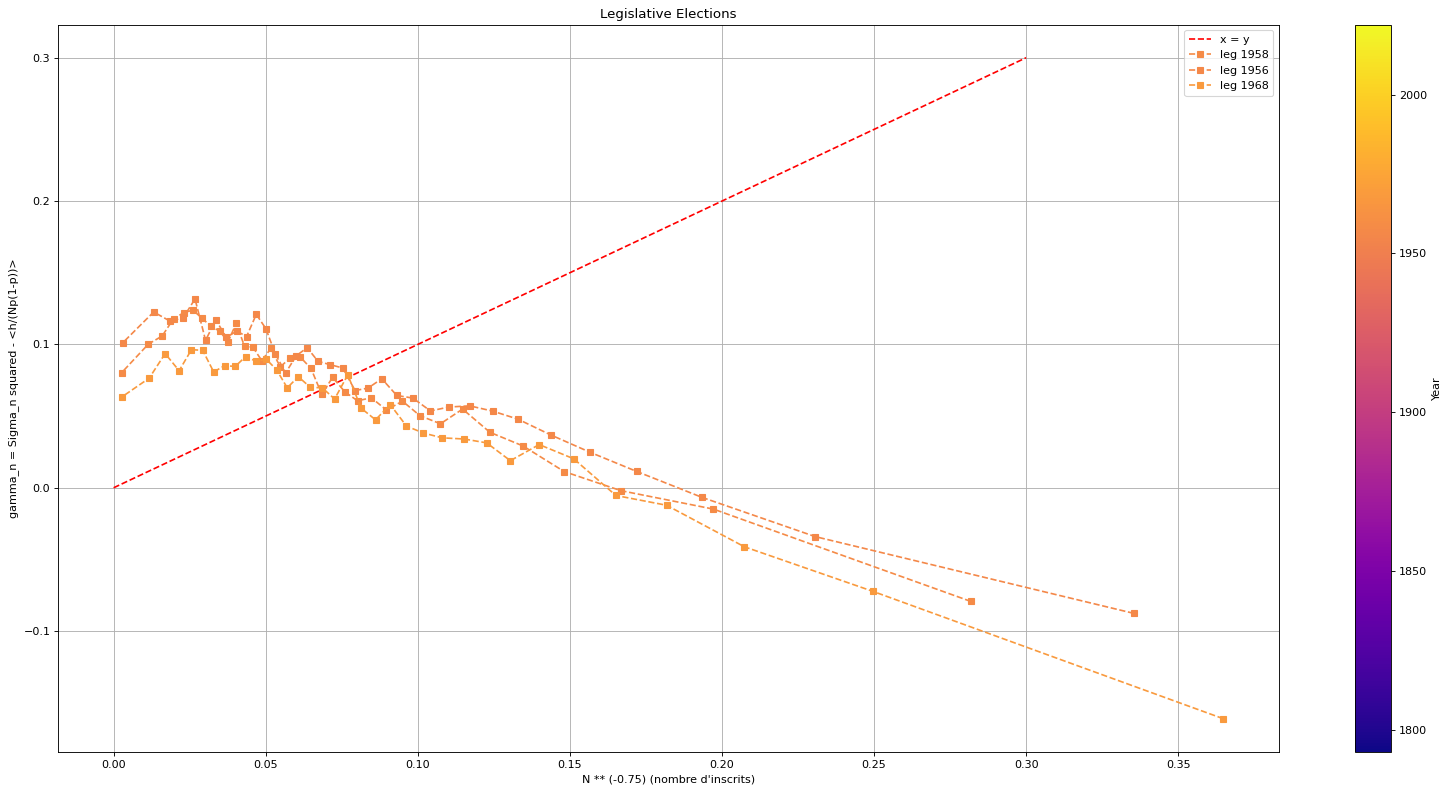

In [30]:
plot_sigma(
    tau_m,
    tau_s,
    bin_avg_values_bin,
    election_type="leg",
    elections_to_remove=[
        "1967",
        "1962",
        "1871",
        "2017",
        "1898",
        "2012",
        "1988",
        "1981",
        "1986",
        "1973",
        "1902",
        "1919",
        "1993",
        "1849",
        "1876",
        "1885",
        "2007",
        "1848",
        "1893",
        "1978",
        "1997",
        "1906",
        "1872",
        "1881",
        "2002",
        "1889",
        "2022",
        "1951",
        "1928",
        "1936",
        "1924",
        "1910",
        "1945",
        "1914",
        "1932",
        "1946",
        "1947",
    ],
    remove_constante_component=False,
    b={},
    remove_component_2=False,
    a={},
)

We find that for a subset of elections (period:1920-1960) there is no evidence of a decreasing turnout rates as the size of the communes grow. And for some of them a not increasing variance.

Intra-commune herding is not constant over time (noise that explains why the variance is not dependent on $N^{-1}$).

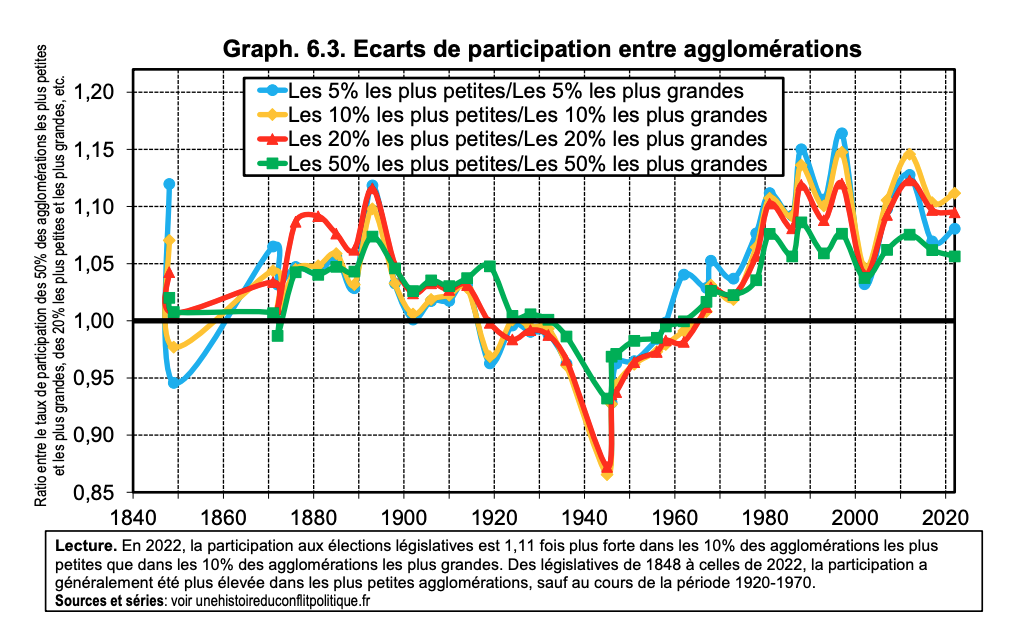

See : https://arxiv.org/abs/1201.0524 for other country. There is different patterns and we have to assume an universal form but that is dependant on the distribution of the population in cities $\rho_{t}(N)$, that has evolved over time.

Estimation : 
- $\beta\sigma^2_{\phi}$ : cultural field (spatial correlation or variance).
- $\sigma^2_{\tau}$ : variance plot.
- $h$ : herding factor (temporal).
- $\beta\sigma^2_{\mu}$ : variance plot (removed constant components).
- $r = \sigma^2_{\mu}/\sigma^2_{\phi}$
- $\omega$ : variance plot.
- $l_c, L, T_{eq}, C, B, \lambda$ : spatial correlations

## 5. Spatial correlations

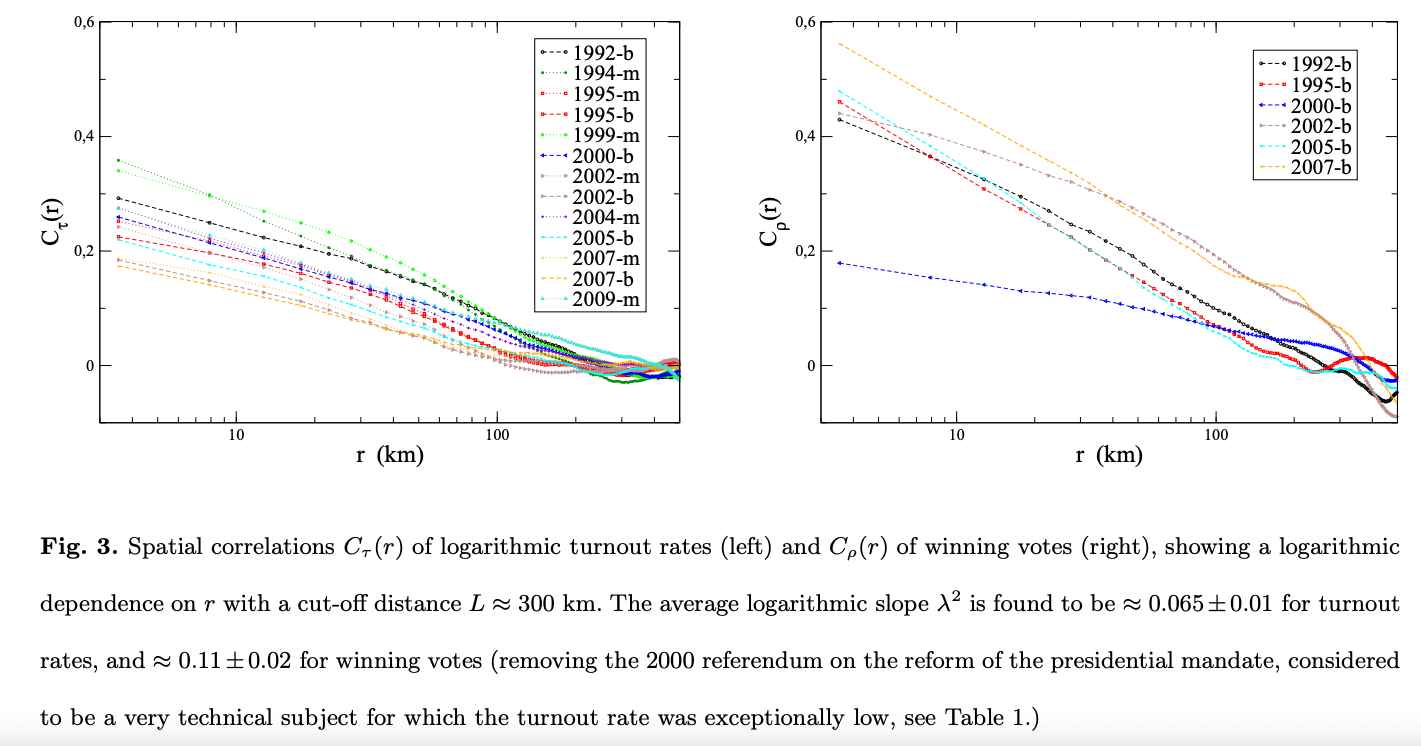

In [22]:
import joblib
import matplotlib.pyplot as plt

In [23]:
def generate_filenames_and_file_labels(directory):
    # List all files in the directory
    files_in_directory = os.listdir(directory)
    filenames = [file for file in files_in_directory if file.endswith(".pkl")]

    # Initialize an empty dictionary to store the file labels
    file_labels = {}

    # Iterate through the files in the directory
    for file in files_in_directory:
        # Check if the file ends with '.pkl'
        if file.endswith(".pkl"):
            # Extract the year from the filename
            year = None
            if "pres" in file:
                # Extract year from the file
                year = "".join([char for char in file if char.isdigit()])
                if len(year) > 4:
                    year = year[1:]
                year = "pres_" + year

            if "ref" in file:
                # Extract year from the file
                year = "".join([char for char in file if char.isdigit()])
                if len(year) > 4:
                    year = year[1:]
                year = "ref_" + year

            if "leg" in file:
                # Extract year from the file
                year = "".join([char for char in file if char.isdigit()])
                if len(year) > 4:
                    year = year[1:]
                year = "leg_" + year

            # Check if it's a T2 file
            if "T2" in file:
                file_labels[file] = f"T2_{year}"
            elif year:
                file_labels[file] = year

    return filenames, file_labels


# Directory containing the .pkl files
d = "../dump/spatial_correlations_dump/"

filenames, file_labels = generate_filenames_and_file_labels(d)

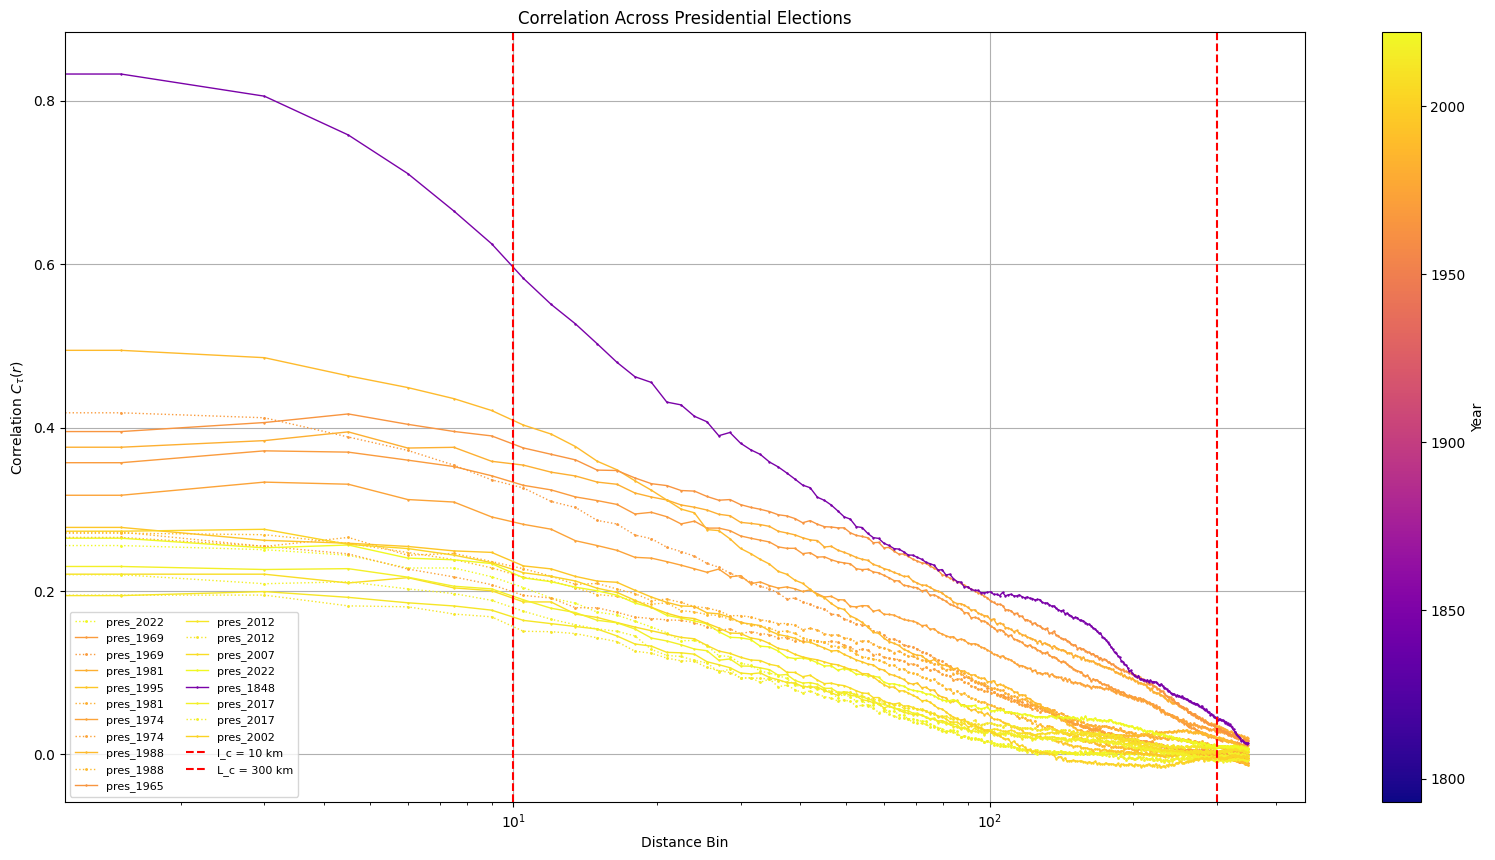

In [24]:
# Initialize a dictionary to store DataFrames
dataframes = {}

# Load and convert .pkl files into DataFrames
for filename in filenames:
    correlation_data = joblib.load(d + filename)
    label = file_labels[filename]  # Use the corresponding label for the file
    dataframes[label] = pd.DataFrame(correlation_data)

# Sort labels by year
filtered_keys = [key for key in dataframes if not key.startswith("T2")]
sorted_labels = sorted(filtered_keys, key=lambda x: int(x.split("_")[-1]))

# Map years to colors using a colormap
years = np.array([int(year.split("_")[-1]) for year in sorted_labels])
colormap = cm.plasma  # Choose a color map
normalize = plt.Normalize(min(years), max(years))
colors = {year: colormap(normalize(year)) for year in years}

# Plot the data on the same graph
fig, ax = plt.subplots(figsize=(20, 10))

# Loop through each DataFrame and plot
for label, df in dataframes.items():
    if "pres" not in label:
        continue
    if label.startswith("T2"):  # For T2 elections, use a different linestyle
        linestyle = ":"  # Dash line for T2 elections
        marker = "o"
        label = label[3:]
    else:
        linestyle = "-"  # Solid line for regular elections
        marker = "+"
    ax.plot(
        df["distance_bin"] * 1.5,  # Adjust distance bin scaling
        df["correlation"],
        label=label,
        linestyle=linestyle,
        color=colors[
            int(label.split("_")[-1])
        ],  # Use the color corresponding to the year
        marker=marker,
        linewidth=1,
        markersize=1,
    )

ax.axvline(x=10, color="red", linestyle="--", label="l_c = 10 km")
ax.axvline(x=300, color="red", linestyle="--", label="L_c = 300 km")
# Add labels and title
ax.set_title("Correlation Across Presidential Elections")
ax.set_xlabel("Distance Bin")
ax.set_xscale("log")
ax.set_ylabel("Correlation $C_{\\tau}(r)$")
ax.legend(ncol=2, fontsize=8)  # Adjust legend for better readability

# Show colorbar to indicate year
sm = cm.ScalarMappable(cmap=colormap, norm=normalize)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)  # Explicitly link the colorbar to the current axes
cbar.set_label("Year")

# Show grid for better readability
ax.grid(True)

# Display the plot
plt.show()

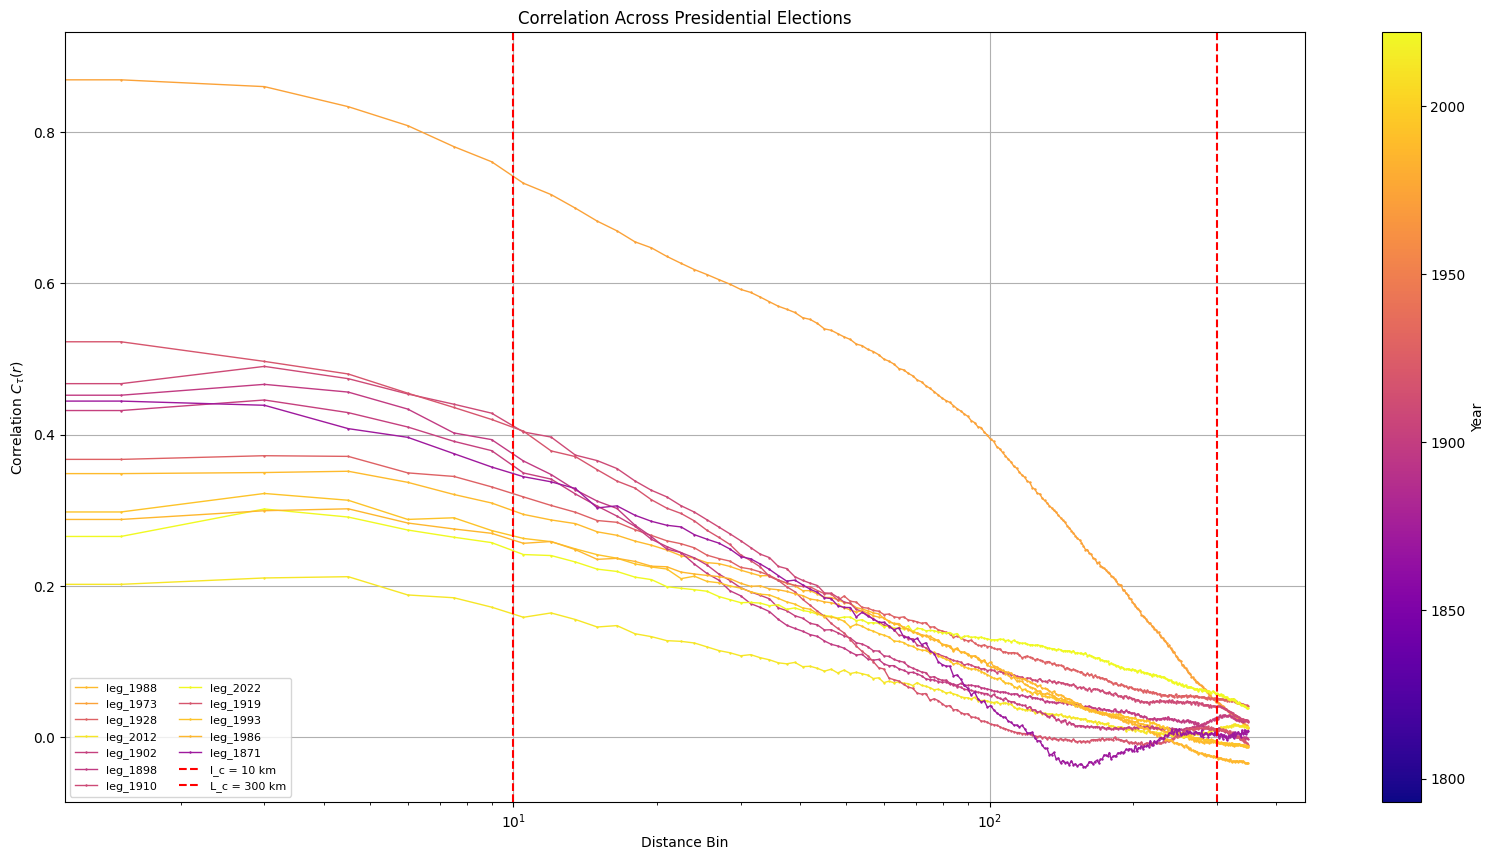

In [25]:
# Initialize a dictionary to store DataFrames
dataframes = {}

# Load and convert .pkl files into DataFrames
for filename in filenames:
    correlation_data = joblib.load(d + filename)
    label = file_labels[filename]  # Use the corresponding label for the file
    dataframes[label] = pd.DataFrame(correlation_data)

# Sort labels by year
filtered_keys = [key for key in dataframes if not key.startswith("T2")]
sorted_labels = sorted(filtered_keys, key=lambda x: int(x.split("_")[-1]))

# Map years to colors using a colormap
years = np.array([int(year.split("_")[-1]) for year in sorted_labels])
colormap = cm.plasma  # Choose a color map
normalize = plt.Normalize(min(years), max(years))
colors = {year: colormap(normalize(year)) for year in years}

# Plot the data on the same graph
fig, ax = plt.subplots(figsize=(20, 10))

# Loop through each DataFrame and plot
for label, df in dataframes.items():
    if "leg" not in label:
        continue
    if label.startswith("T2"):  # For T2 elections, use a different linestyle
        linestyle = ":"  # Dash line for T2 elections
        marker = "o"
        label = label[3:]
    else:
        linestyle = "-"  # Solid line for regular elections
        marker = "+"
    ax.plot(
        df["distance_bin"] * 1.5,  # Adjust distance bin scaling
        df["correlation"],
        label=label,
        linestyle=linestyle,
        color=colors[
            int(label.split("_")[-1])
        ],  # Use the color corresponding to the year
        marker=marker,
        linewidth=1,
        markersize=1,
    )

ax.axvline(x=10, color="red", linestyle="--", label="l_c = 10 km")
ax.axvline(x=300, color="red", linestyle="--", label="L_c = 300 km")
# Add labels and title
ax.set_title("Correlation Across Presidential Elections")
ax.set_xlabel("Distance Bin")
ax.set_xscale("log")
ax.set_ylabel("Correlation $C_{\\tau}(r)$")
ax.legend(ncol=2, fontsize=8)  # Adjust legend for better readability

# Show colorbar to indicate year
sm = cm.ScalarMappable(cmap=colormap, norm=normalize)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)  # Explicitly link the colorbar to the current axes
cbar.set_label("Year")

# Show grid for better readability
ax.grid(True)

# Display the plot
plt.show()

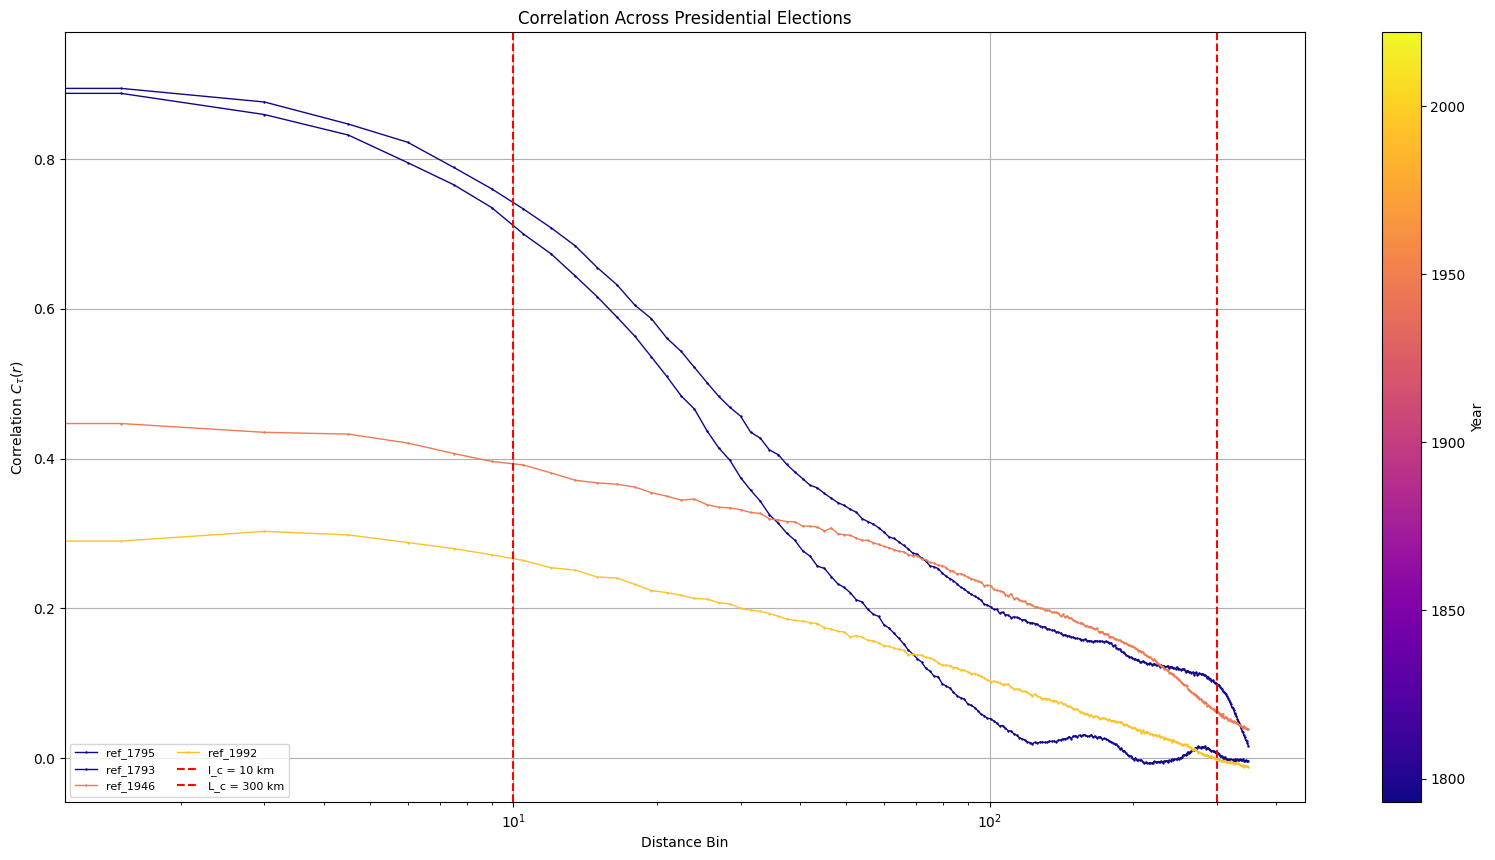

In [26]:
# Initialize a dictionary to store DataFrames
dataframes = {}

# Load and convert .pkl files into DataFrames
for filename in filenames:
    correlation_data = joblib.load(d + filename)
    label = file_labels[filename]  # Use the corresponding label for the file
    dataframes[label] = pd.DataFrame(correlation_data)

# Sort labels by year
filtered_keys = [key for key in dataframes if not key.startswith("T2")]
sorted_labels = sorted(filtered_keys, key=lambda x: int(x.split("_")[-1]))

# Map years to colors using a colormap
years = np.array([int(year.split("_")[-1]) for year in sorted_labels])
colormap = cm.plasma  # Choose a color map
normalize = plt.Normalize(min(years), max(years))
colors = {year: colormap(normalize(year)) for year in years}

# Plot the data on the same graph
fig, ax = plt.subplots(figsize=(20, 10))

# Loop through each DataFrame and plot
for label, df in dataframes.items():
    if "ref" not in label:
        continue
    if label.startswith("T2"):  # For T2 elections, use a different linestyle
        linestyle = ":"  # Dash line for T2 elections
        marker = "o"
        label = label[3:]
    else:
        linestyle = "-"  # Solid line for regular elections
        marker = "+"
    ax.plot(
        df["distance_bin"] * 1.5,  # Adjust distance bin scaling
        df["correlation"],
        label=label,
        linestyle=linestyle,
        color=colors[
            int(label.split("_")[-1])
        ],  # Use the color corresponding to the year
        marker=marker,
        linewidth=1,
        markersize=1,
    )

ax.axvline(x=10, color="red", linestyle="--", label="l_c = 10 km")
ax.axvline(x=300, color="red", linestyle="--", label="L_c = 300 km")
# Add labels and title
ax.set_title("Correlation Across Presidential Elections")
ax.set_xlabel("Distance Bin")
ax.set_xscale("log")
ax.set_ylabel("Correlation $C_{\\tau}(r)$")
ax.legend(ncol=2, fontsize=8)  # Adjust legend for better readability

# Show colorbar to indicate year
sm = cm.ScalarMappable(cmap=colormap, norm=normalize)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)  # Explicitly link the colorbar to the current axes
cbar.set_label("Year")

# Show grid for better readability
ax.grid(True)

# Display the plot
plt.show()

**This fact holds for all elections and the correlation is even stronger the older the election is. We find for all election long-distance correlations. The cutoff distance however is always found to be around 300 km (the radius of France).**

This can be linked to a change of $l_c(t)$ over time (see simulations results). AS $l_c$ is geographically determined, it indicates that the structure of the country has changed.

## 6. Conclusion

TODO: temporel dependance of the cultural field. Used to estimate herding factor.

Investigate time correlations